# Autoencoder Baseline -- One-Class Classification

## Ziel

Wir zeigen dem Modell **nur gute Ruderschlaege**. Danach entscheidet es:
> Ist dieser neue Schlag aehnlich genug zu dem, was ich gelernt habe?

Das ist ein **One-Class Classification** Problem (auch: Anomalieerkennung).
- Klasse 0 (Normal): guter Schlag
- Alles andere: schlechter Schlag (Anomalie)

---

## Was ist ein Autoencoder?

Ein Autoencoder ist ein neuronales Netz mit zwei Teilen:

```
Input (Sequenz) --> [ENCODER] --> Bottleneck --> [DECODER] --> Rekonstruktion
```

- **Encoder**: komprimiert die Eingabe auf eine kleine Repraesentation (Bottleneck)
- **Decoder**: versucht, die Eingabe aus dem Bottleneck zu rekonstruieren
- **Verlust**: Mean Squared Error zwischen Input und Rekonstruktion

Das Modell lernt, **gute Schlaege gut zu rekonstruieren**. Fuer schlechte Schlaege ist der Rekonstruktionsfehler hoch -- das ist das Erkennungssignal.

---

## LSTM vs. Conv1D

| | LSTM | Conv1D |
|---|---|---|
| **Was es tut** | Merkt sich vergangene Schritte (Gedaechtnis) | Sucht lokale Muster im Zeitfenster |
| **Gut fuer** | Rhythmus, Langzeit-Abhaengigkeiten | Kurze charakteristische Bewegungsmuster |
| **Geschwindigkeit** | Langsamer | Schneller |
| **Wir waehlen** | Ja | Nein |

**LSTM** ist besser geeignet, weil der Gesamtrhythmus (Vorlage -> Antrieb -> Endzug) ueber die ganze Sequenz wichtig ist.


In [31]:
!pip install tensorflow


[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'requirements.txt').exists()
)
NORM_DIR = PROJECT_ROOT / '1_DatasetCharacteristics' / 'landmarks' / 'normalized'
RAW_DIR  = PROJECT_ROOT / '1_DatasetCharacteristics' / 'landmarks'

print('TensorFlow:', tf.__version__)
print('Project root:', PROJECT_ROOT)


TensorFlow: 2.21.0
Project root: /Users/clarabrilke/ML projects/ML-project


In [33]:
# --- Gute Schlaege ---
df_good = pd.read_csv(NORM_DIR / 'landmarks_all_norm_10fps.csv')

exclude = {'phase', 'GOOD', 'BAD'}
feature_cols = [c for c in df_good.columns if c not in exclude]
X_good = df_good[feature_cols].values

print(f'Gute Schlaege: {X_good.shape[0]} Frames, {X_good.shape[1]} Features')

# --- Schlechte Schlaege  ---
df_bad = pd.read_csv(NORM_DIR / 'cla-BAD-landmarks-norm_10fps.csv')
X_bad = df_bad[feature_cols].values

print(f'Schlechte Schlaege: {X_bad.shape[0]} Frames, {X_bad.shape[1]} Features')
print(f'Feature-Spalten stimmen ueberein: {X_good.shape[1] == X_bad.shape[1]}')


Gute Schlaege: 11244 Frames, 66 Features
Schlechte Schlaege: 506 Frames, 66 Features
Feature-Spalten stimmen ueberein: True


## Normalisierung

Beide Datensaetze wurden durch die gleiche koerperrelative Mediapipe-Normalisierung verarbeitet.
Ein zusaetzlicher StandardScaler ist nicht mehr noetig -- die Skalen sind bereits vergleichbar.


In [34]:
# Beide Datensaetze laufen durch die gleiche Mediapipe-Normalisierung --
# kein zusaetzlicher StandardScaler noetig.
X_good_scaled = X_good
X_bad_scaled  = X_bad

print('Gute Schlaege   -- Mittelwert:', X_good_scaled.mean().round(4), 'Std:', X_good_scaled.std().round(4))
print('Schlechte Schlaege -- Mittelwert:', X_bad_scaled.mean().round(4),  'Std:', X_bad_scaled.std().round(4))


Gute Schlaege   -- Mittelwert: -0.4593 Std: 0.6462
Schlechte Schlaege -- Mittelwert: -0.5008 Std: 0.6337


## Sliding Window -- Frames zu Sequenzen

Ein LSTM verarbeitet **Sequenzen**, keine einzelnen Frames.
Wir schneiden den Datenstrom mit einem gleitenden Fenster:

```
Frame:  [0,1,2,...,23]  --> Sequenz 1
        [12,13,...,35]  --> Sequenz 2  (50% Ueberlappung)
        ...
```

- **Fenstergroesse** = 24 Frames (~1 Ruderschlag bei 10 fps)
- **Stride** = 12 Frames (50% Ueberlappung --> mehr Trainingsdaten)


In [35]:
WINDOW_SIZE = 24
STRIDE      = 12

def create_windows(X, window_size=WINDOW_SIZE, stride=STRIDE):
    windows = []
    for start in range(0, len(X) - window_size + 1, stride):
        windows.append(X[start : start + window_size])
    return np.array(windows)

X_good_seq = create_windows(X_good_scaled)
X_bad_seq  = create_windows(X_bad_scaled)

print(f'Gute Sequenzen:      {X_good_seq.shape}  (n_sequenzen, frames, features)')
print(f'Schlechte Sequenzen: {X_bad_seq.shape}')


Gute Sequenzen:      (936, 24, 66)  (n_sequenzen, frames, features)
Schlechte Sequenzen: (41, 24, 66)


In [36]:
# Train / Validation Split -- nur gute Sequenzen
# Kein shuffle: zeitliche Reihenfolge erhalten
n_total = len(X_good_seq)
n_train = int(n_total * 0.8)

X_train = X_good_seq[:n_train]
X_val   = X_good_seq[n_train:]

print(f'Training:   {X_train.shape[0]} Sequenzen')
print(f'Validation: {X_val.shape[0]} Sequenzen')
print(f'Schlechte (nur Evaluation): {X_bad_seq.shape[0]} Sequenzen')


Training:   748 Sequenzen
Validation: 188 Sequenzen
Schlechte (nur Evaluation): 41 Sequenzen


## LSTM Autoencoder -- Architektur

```
Input: (24 Frames x 66 Features)
        |
  LSTM(128)         <-- verarbeitet die Sequenz, Ausgabe nur letzter Schritt
        |
  Dense(32)         <-- Bottleneck: komprimierte Repraesentation des Schlags
        |
  RepeatVector(24)  <-- dupliziert den Bottleneck fuer jeden Zeitschritt
        |
  LSTM(128, return_sequences=True)  <-- rekonstruiert die Sequenz
        |
  TimeDistributed(Dense(66))  <-- ein Output-Vektor pro Zeitschritt
        |
Output: (24 Frames x 66 Features) -- Rekonstruktion
```

**Loss**: MSE zwischen Input und Rekonstruktion.  
**Anomalie-Score**: mittlerer MSE ueber alle Zeitschritte einer Sequenz.


In [37]:
n_timesteps = WINDOW_SIZE
n_features  = X_train.shape[2]
LATENT_DIM  = 32

def build_lstm_autoencoder(timesteps, features, latent_dim):
    inputs = keras.Input(shape=(timesteps, features), name='input')

    # Encoder
    x = layers.LSTM(128, return_sequences=False, name='encoder_lstm')(inputs)
    bottleneck = layers.Dense(latent_dim, activation='relu', name='bottleneck')(x)

    # Decoder
    x = layers.RepeatVector(timesteps, name='repeat')(bottleneck)
    x = layers.LSTM(128, return_sequences=True, name='decoder_lstm')(x)
    outputs = layers.TimeDistributed(layers.Dense(features), name='output')(x)

    return keras.Model(inputs, outputs, name='LSTM_Autoencoder')

model = build_lstm_autoencoder(n_timesteps, n_features, LATENT_DIM)
model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 66)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm (LSTM)             │ (None, 128)            │        99,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm (LSTM)             │ (None, 24, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 24, 66)         │         8,514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,914 (761.38 KB)

 Trainable params: 194,914 (761.38 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
EPOCHS     = 50
BATCH_SIZE = 32

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,            # Autoencoder: Input = Target
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.2363 - val_loss: 0.1253
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0878 - val_loss: 0.1096
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0820 - val_loss: 0.1076
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0810 - val_loss: 0.1070
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0806 - val_loss: 0.1065
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0805 - val_loss: 0.1060
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0803 - val_loss: 0.1053
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0798 - val_loss: 0.1030
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0788 - val_loss: 0.0990
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0776 - val_loss: 0.0954
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0763 - val_loss: 0.0905
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0

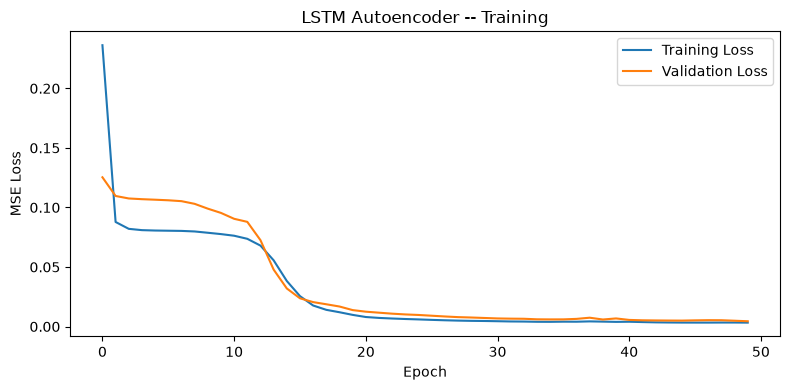

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'],     label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Autoencoder -- Training')
ax.legend()
plt.tight_layout()
plt.show()


## Schwellenwert (Threshold)

Wir berechnen den Rekonstruktionsfehler (MSE) fuer alle Trainingssequenzen.
Als Schwellenwert waehlen wir das **95. Perzentil** der Trainings-Fehler:

> Sequenzen mit MSE > Threshold --> **schlechter Schlag**

Der Threshold kann angepasst werden (z.B. 99. Perzentil = strenger, weniger False Positives).


In [40]:
def reconstruction_error(model, X):
    X_pred = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_pred), axis=(1, 2))

train_errors = reconstruction_error(model, X_train)
val_errors   = reconstruction_error(model, X_val)
bad_errors   = reconstruction_error(model, X_bad_seq)

THRESHOLD_PERCENTILE = 95
threshold = np.percentile(train_errors, THRESHOLD_PERCENTILE)

print(f'Threshold ({THRESHOLD_PERCENTILE}. Perzentil der Trainingsfehler): {threshold:.6f}')
print(f'Mittlerer Fehler -- Training:   {train_errors.mean():.6f}')
print(f'Mittlerer Fehler -- Validation: {val_errors.mean():.6f}')
print(f'Mittlerer Fehler -- Schlechte:  {bad_errors.mean():.6f}')


Threshold (95. Perzentil der Trainingsfehler): 0.006103
Mittlerer Fehler -- Training:   0.003041
Mittlerer Fehler -- Validation: 0.004447
Mittlerer Fehler -- Schlechte:  0.006661


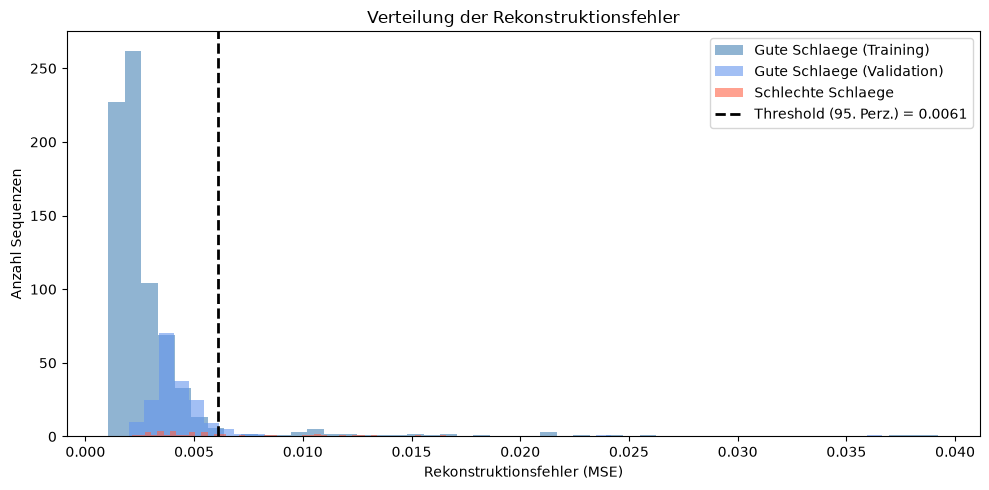

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_errors, bins=50, alpha=0.6, label='Gute Schlaege (Training)',  color='steelblue')
ax.hist(val_errors,   bins=50, alpha=0.6, label='Gute Schlaege (Validation)', color='cornflowerblue')
ax.hist(bad_errors,   bins=50, alpha=0.6, label='Schlechte Schlaege',         color='tomato')
ax.axvline(threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold ({THRESHOLD_PERCENTILE}. Perz.) = {threshold:.4f}')
ax.set_xlabel('Rekonstruktionsfehler (MSE)')
ax.set_ylabel('Anzahl Sequenzen')
ax.set_title('Verteilung der Rekonstruktionsfehler')
ax.legend()
plt.tight_layout()
plt.show()


## Evaluation

Wir kombinieren Validierungs-Sequenzen (gut) und schlechte Sequenzen:
- **Label 0** = gut (Fehler <= Threshold)
- **Label 1** = schlecht (Fehler > Threshold)

| Metrik | Bedeutung |
|---|---|
| **Recall (schlecht)** | Wie viele schlechte Schlaege erkennen wir? |
| **Precision (schlecht)** | Wie oft haben wir Recht, wenn wir 'schlecht' sagen? |
| **ROC-AUC** | Trennschaerfe unabhaengig vom Threshold |


  Evaluation (Validation + Schlechte Schlaege)
              precision    recall  f1-score   support

         Gut       0.88      0.94      0.91       188
    Schlecht       0.59      0.39      0.47        41

    accuracy                           0.84       229
   macro avg       0.73      0.67      0.69       229
weighted avg       0.83      0.84      0.83       229

ROC-AUC: 0.6714


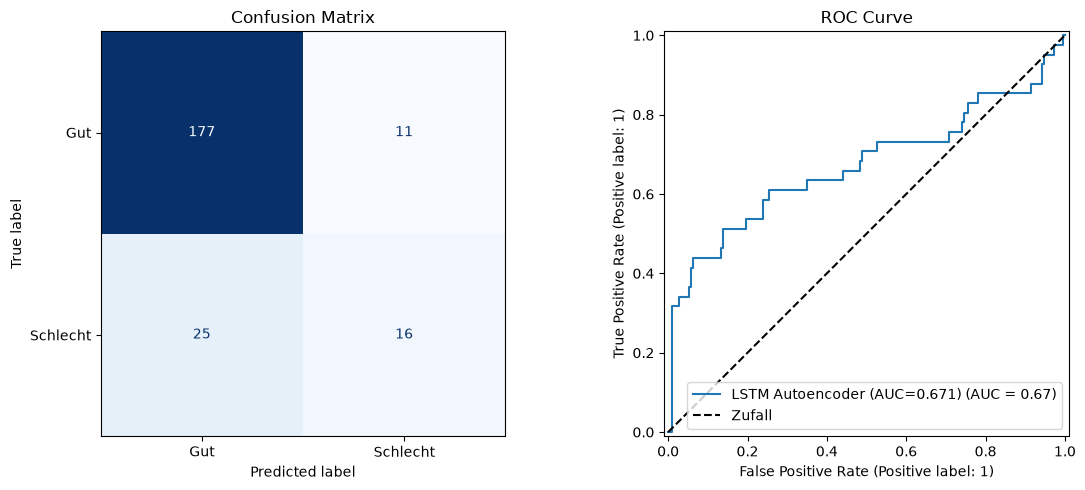

In [42]:
y_scores = np.concatenate([val_errors, bad_errors])
y_true   = np.array([0] * len(val_errors) + [1] * len(bad_errors))
y_pred   = (y_scores > threshold).astype(int)

print('=' * 50)
print('  Evaluation (Validation + Schlechte Schlaege)')
print('=' * 50)
print(classification_report(y_true, y_pred, target_names=['Gut', 'Schlecht']))

auc = roc_auc_score(y_true, y_scores)
print(f'ROC-AUC: {auc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred),
    display_labels=['Gut', 'Schlecht']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(
    y_true, y_scores,
    name=f'LSTM Autoencoder (AUC={auc:.3f})',
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], 'k--', label='Zufall')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


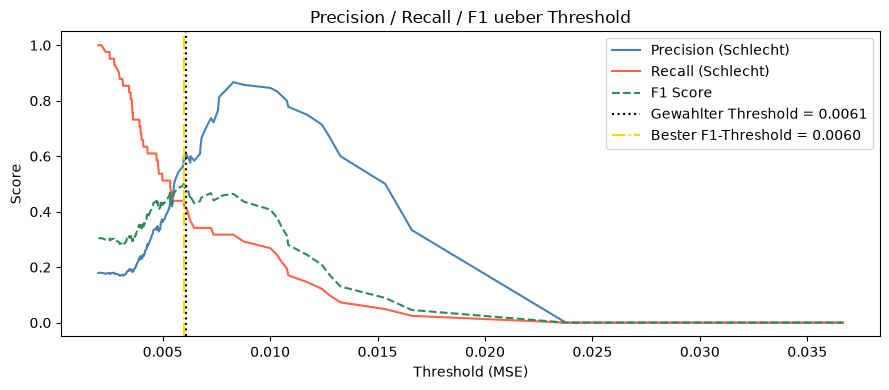

Bester F1-Score: 0.5070 bei Threshold 0.005978


In [43]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, y_scores, pos_label=1)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx  = np.argmax(f1_scores)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precision[:-1], label='Precision (Schlecht)', color='steelblue')
ax.plot(thresholds, recall[:-1],    label='Recall (Schlecht)',    color='tomato')
ax.plot(thresholds, f1_scores[:-1], label='F1 Score',             color='seagreen', linestyle='--')
ax.axvline(threshold, color='black', linestyle=':',
           label=f'Gewahlter Threshold = {threshold:.4f}')
ax.axvline(thresholds[best_idx], color='gold', linestyle='-.',
           label=f'Bester F1-Threshold = {thresholds[best_idx]:.4f}')
ax.set_xlabel('Threshold (MSE)')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 ueber Threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Bester F1-Score: {f1_scores[best_idx]:.4f} bei Threshold {thresholds[best_idx]:.6f}')


## Zusammenfassung

### Ergebnisse

*(nach Ausfuehren mit Werten befuellen)*

| | Wert |
|---|---|
| **Threshold** (95. Perz.) | -- |
| **ROC-AUC** | -- |
| **Recall (Schlecht)** | -- |
| **Precision (Schlecht)** | -- |

### Einschraenkungen dieses Baselines

- **Sliding Window ignoriert Schlaggrenzen**: Ein Fenster kann ueber zwei Schlaege gehen
- **Nur ein Athlet mit schlechten Schlaegen** (cla-BAD) -- begrenzte Generalisierung

### Naechste Schritte (Ordner 3)

- Sequenzen an echten Schlaggrenzen schneiden (strokes.csv) statt Sliding Window
- Variational Autoencoder (VAE) fuer besser strukturierten Latenzraum
- Threshold automatisch optimieren (maximaler F1)
